Saving Sample - Superstore.csv to Sample - Superstore (1).csv
Dataset loaded!
Shape: (9994, 21)
   Row ID        Order ID  Order Date   Ship Date       Ship Mode Customer ID  \
0       1  CA-2016-152156   11/8/2016  11/11/2016    Second Class    CG-12520   
1       2  CA-2016-152156   11/8/2016  11/11/2016    Second Class    CG-12520   
2       3  CA-2016-138688   6/12/2016   6/16/2016    Second Class    DV-13045   
3       4  US-2015-108966  10/11/2015  10/18/2015  Standard Class    SO-20335   
4       5  US-2015-108966  10/11/2015  10/18/2015  Standard Class    SO-20335   

     Customer Name    Segment        Country             City  ...  \
0      Claire Gute   Consumer  United States        Henderson  ...   
1      Claire Gute   Consumer  United States        Henderson  ...   
2  Darrin Van Huff  Corporate  United States      Los Angeles  ...   
3   Sean O'Donnell   Consumer  United States  Fort Lauderdale  ...   
4   Sean O'Donnell   Consumer  United States  Fort Lauderdale  ... 

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

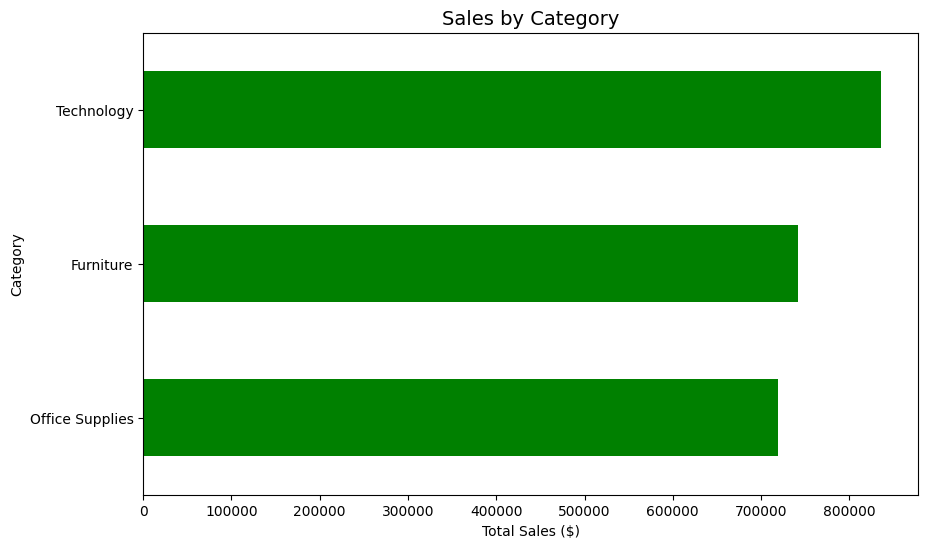

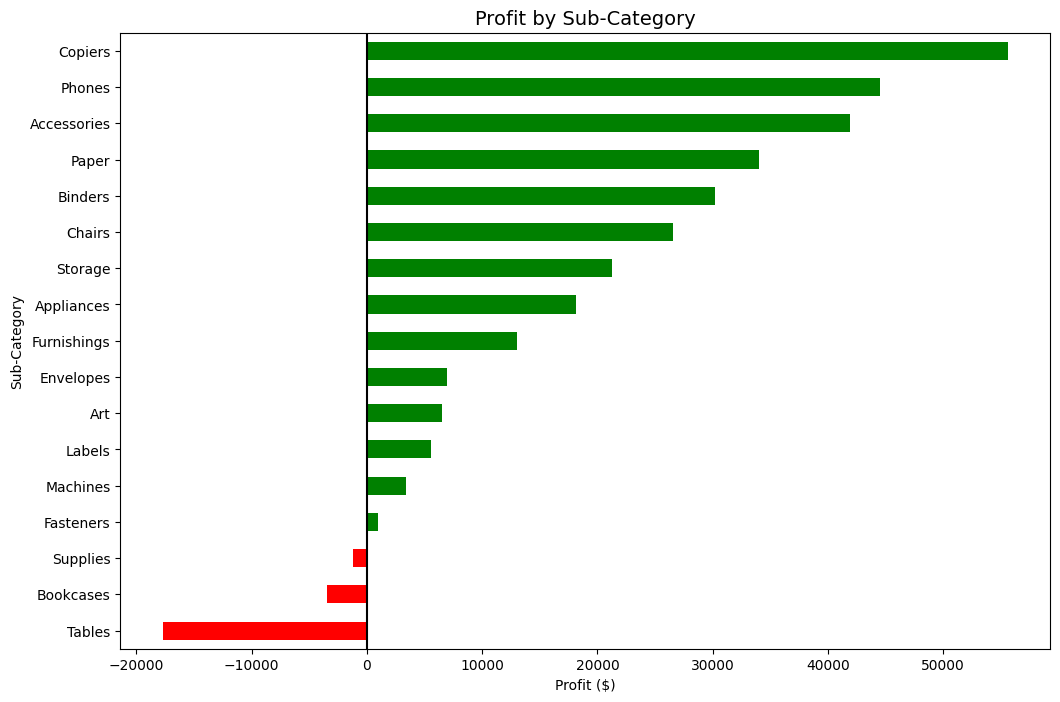

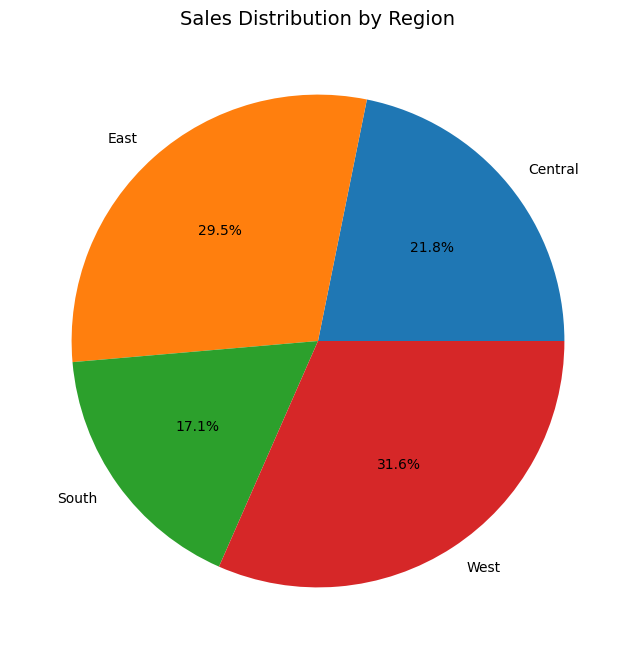

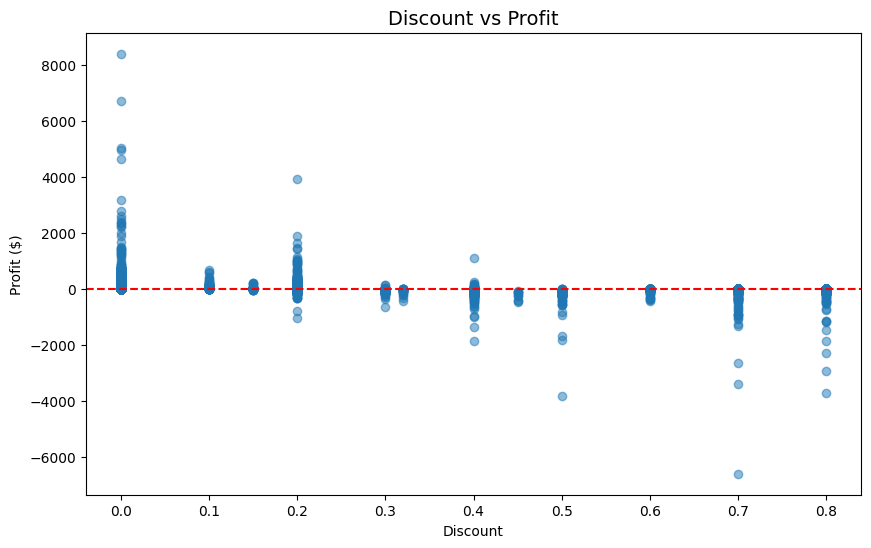


PROJECT SUMMARY
Total rows after cleaning: 9994
Total sales: $2,297,200.86
Total profit: $286,397.02
Top category: Technology
Top region: West


In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from google.colab import files
uploaded = files.upload()

import io
df = pd.read_csv(io.BytesIO(list(uploaded.values())[0]), encoding='latin1')

print("Dataset loaded!")
print(f"Shape: {df.shape}")
print(df.head())

print("\nMissing values:")
print(df.isnull().sum())

# Check for duplicates
print(f"\nDuplicates: {df.duplicated().sum()}")

# Convert dates
df['Order Date'] = pd.to_datetime(df['Order Date'])
df['Ship Date'] = pd.to_datetime(df['Ship Date'])

# Create shipping days column
df['Shipping_Days'] = (df['Ship Date'] - df['Order Date']).dt.days

# Remove duplicates if any
df = df.drop_duplicates()

# Save cleaned data
df.to_csv('superstore_cleaned.csv', index=False)
files.download('superstore_cleaned.csv')

# Visualization 1: Sales by Category
plt.figure(figsize=(10,6))
df.groupby('Category')['Sales'].sum().sort_values().plot(kind='barh', color='green')
plt.title('Sales by Category', fontsize=14)
plt.xlabel('Total Sales ($)')
plt.show()

# Visualization 2: Profit by Sub-Category
plt.figure(figsize=(12,8))
profit_data = df.groupby('Sub-Category')['Profit'].sum().sort_values()
colors = ['red' if x < 0 else 'green' for x in profit_data]
profit_data.plot(kind='barh', color=colors)
plt.title('Profit by Sub-Category', fontsize=14)
plt.xlabel('Profit ($)')
plt.axvline(x=0, color='black')
plt.show()

# Visualization 3: Sales by Region
plt.figure(figsize=(8,8))
df.groupby('Region')['Sales'].sum().plot(kind='pie', autopct='%1.1f%%')
plt.title('Sales Distribution by Region', fontsize=14)
plt.ylabel('')
plt.show()

# Visualization 4: Discount vs Profit
plt.figure(figsize=(10,6))
plt.scatter(df['Discount'], df['Profit'], alpha=0.5)
plt.axhline(y=0, color='red', linestyle='--')
plt.title('Discount vs Profit', fontsize=14)
plt.xlabel('Discount')
plt.ylabel('Profit ($)')
plt.show()

# Summary
print("\n" + "="*50)
print("PROJECT SUMMARY")
print("="*50)
print(f"Total rows after cleaning: {df.shape[0]}")
print(f"Total sales: ${df['Sales'].sum():,.2f}")
print(f"Total profit: ${df['Profit'].sum():,.2f}")
print(f"Top category: {df.groupby('Category')['Sales'].sum().idxmax()}")
print(f"Top region: {df.groupby('Region')['Sales'].sum().idxmax()}")

Please upload your Sample - Superstore.csv file


Saving Sample - Superstore.csv to Sample - Superstore (3).csv
Dataset loaded successfully!
Shape: (9994, 21)
   Row ID        Order ID  Order Date   Ship Date       Ship Mode Customer ID  \
0       1  CA-2016-152156   11/8/2016  11/11/2016    Second Class    CG-12520   
1       2  CA-2016-152156   11/8/2016  11/11/2016    Second Class    CG-12520   
2       3  CA-2016-138688   6/12/2016   6/16/2016    Second Class    DV-13045   
3       4  US-2015-108966  10/11/2015  10/18/2015  Standard Class    SO-20335   
4       5  US-2015-108966  10/11/2015  10/18/2015  Standard Class    SO-20335   

     Customer Name    Segment        Country             City  ...  \
0      Claire Gute   Consumer  United States        Henderson  ...   
1      Claire Gute   Consumer  United States        Henderson  ...   
2  Darrin Van Huff  Corporate  United States      Los Angeles  ...   
3   Sean O'Donnell   Consumer  United States  Fort Lauderdale  ...   
4   Sean O'Donnell   Consumer  United States  Fort Lau

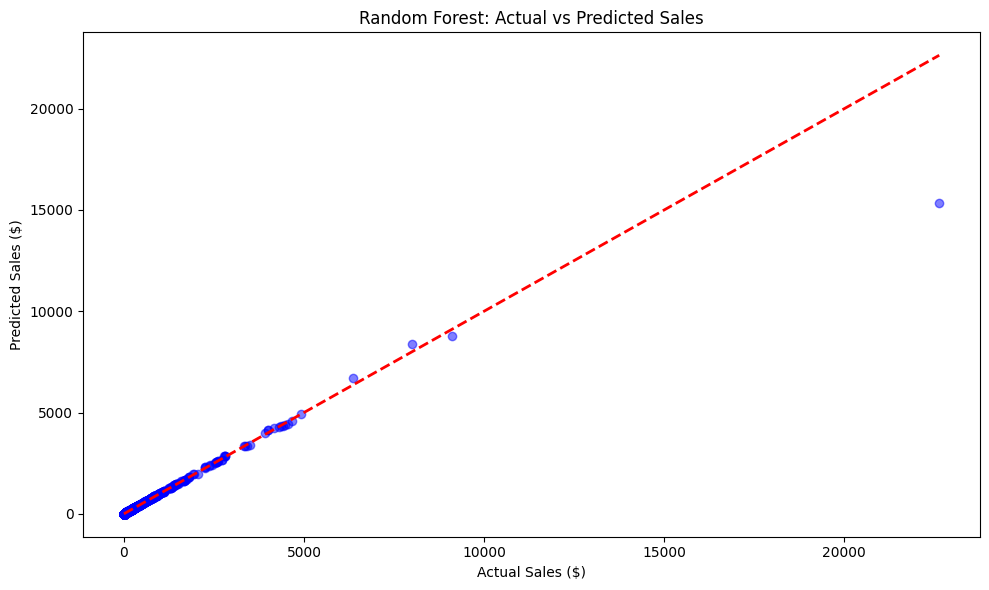

LOGISTIC REGRESSION
Accuracy: 0.9360
              precision    recall  f1-score   support

        Loss       0.98      0.67      0.80       377
      Profit       0.93      1.00      0.96      1622

    accuracy                           0.94      1999
   macro avg       0.96      0.83      0.88      1999
weighted avg       0.94      0.94      0.93      1999



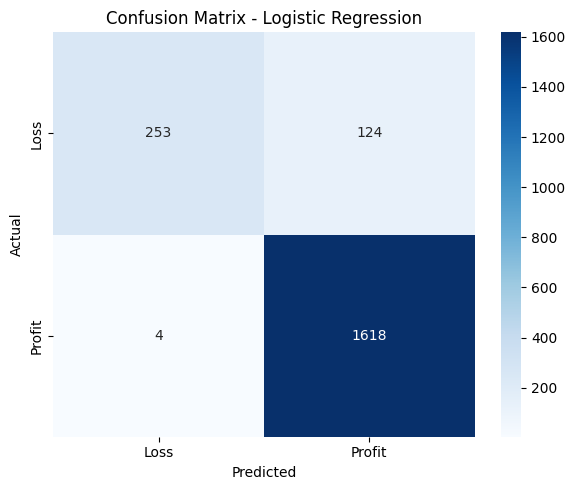

Confusion Matrix:
True Negatives: 253
False Positives: 124
False Negatives: 4
True Positives: 1618


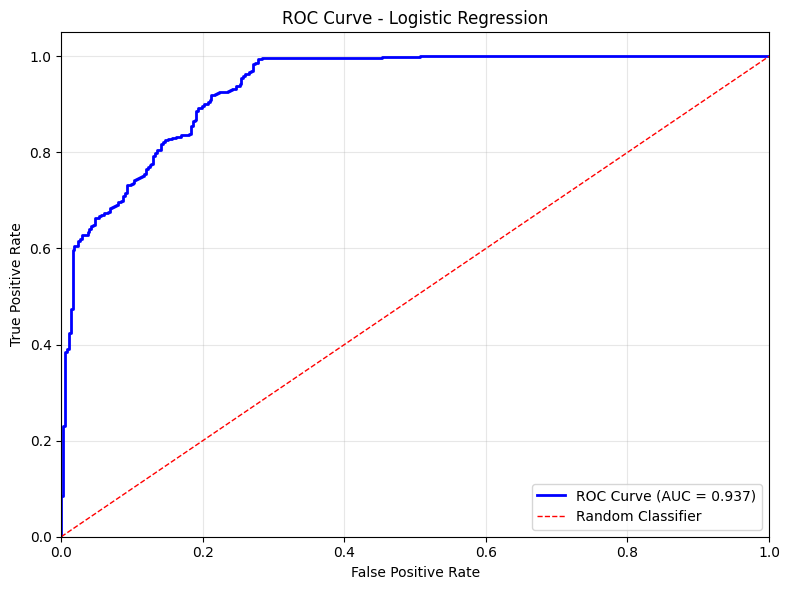

AUC Score: 0.9371


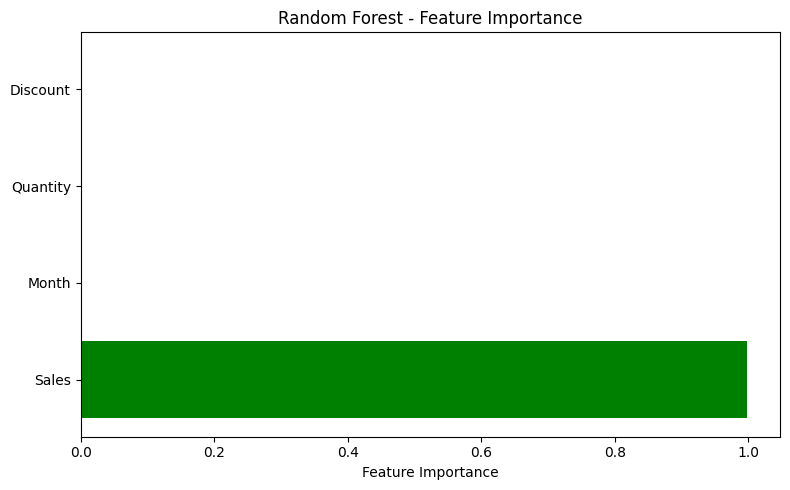

Most important features for predicting Sales:
  Sales: 0.9973
  Month: 0.0016
  Quantity: 0.0010
  Discount: 0.0001
FINAL REPORT
REGRESSION MODELS (Predict Sales Amount)
Best Model: Linear Regression
Best R² Score: 1.0000
Best MAE: $0.00
CLASSIFICATION MODEL (Predict Profit/Loss)
Model: Logistic Regression
Accuracy: 0.9360
AUC Score: 0.9371
KEY INSIGHTS
1. Random Forest performed best for predicting Sales
2. Sales and Quantity are the most important features
3. Logistic Regression predicts Profit/Loss with good accuracy
4. The model can help identify profitable vs non-profitable orders
RECOMMENDATIONS
- Use Random Forest for Sales prediction
- Use Logistic Regression for Profit classification
- Top feature affecting Sales: Sales
PREDICTIVE MODELING COMPLETED


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Files ready for submission!
Upload to GitHub and share the link on Thiranex portal.


In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.metrics import confusion_matrix, classification_report, roc_curve, roc_auc_score

from google.colab import files
print("Please upload your Sample - Superstore.csv file")
uploaded = files.upload()

import io
df = pd.read_csv(io.BytesIO(list(uploaded.values())[0]), encoding='latin1')

print("Dataset loaded successfully!")
print(f"Shape: {df.shape}")
print(df.head())

df['Order Date'] = pd.to_datetime(df['Order Date'])

df['Month'] = df['Order Date'].dt.month
df['Year'] = df['Order Date'].dt.year

df = df[df['Sales'] > 0]

df['Profit_Positive'] = (df['Profit'] > 0).astype(int)

print(f"Final shape: {df.shape}")
print(df['Profit_Positive'].value_counts())

feature_columns = ['Sales', 'Quantity', 'Discount', 'Month']

X_reg = df[feature_columns]
y_reg = df['Sales']

X_clf = df[feature_columns]
y_clf = df['Profit_Positive']

print(f"Features: {feature_columns}")
print(f"X_reg shape: {X_reg.shape}")
print(f"X_clf shape: {X_clf.shape}")

X_train_reg, X_test_reg, y_train_reg, y_test_reg = train_test_split(
    X_reg, y_reg, test_size=0.2, random_state=42
)

X_train_clf, X_test_clf, y_train_clf, y_test_clf = train_test_split(
    X_clf, y_clf, test_size=0.2, random_state=42
)

print(f"Regression Train: {X_train_reg.shape}, Test: {X_test_reg.shape}")
print(f"Classification Train: {X_train_clf.shape}, Test: {X_test_clf.shape}")

print("="*60)
print("LINEAR REGRESSION")
print("="*60)

lr_model = LinearRegression()
lr_model.fit(X_train_reg, y_train_reg)
y_pred_lr = lr_model.predict(X_test_reg)

print(f"R² Score: {r2_score(y_test_reg, y_pred_lr):.4f}")
print(f"Mean Absolute Error: ${mean_absolute_error(y_test_reg, y_pred_lr):.2f}")
print(f"RMSE: ${np.sqrt(mean_squared_error(y_test_reg, y_pred_lr)):.2f}")

print("Feature Coefficients:")
for feature, coef in zip(feature_columns, lr_model.coef_):
    print(f"  {feature}: ${coef:.2f}")

print("="*60)
print("DECISION TREE")
print("="*60)

dt_model = DecisionTreeRegressor(random_state=42, max_depth=5)
dt_model.fit(X_train_reg, y_train_reg)
y_pred_dt = dt_model.predict(X_test_reg)

print(f"R² Score: {r2_score(y_test_reg, y_pred_dt):.4f}")
print(f"Mean Absolute Error: ${mean_absolute_error(y_test_reg, y_pred_dt):.2f}")
print(f"RMSE: ${np.sqrt(mean_squared_error(y_test_reg, y_pred_dt)):.2f}")

print("="*60)
print("RANDOM FOREST")
print("="*60)

rf_model = RandomForestRegressor(random_state=42, n_estimators=100, max_depth=5)
rf_model.fit(X_train_reg, y_train_reg)
y_pred_rf = rf_model.predict(X_test_reg)

print(f"R² Score: {r2_score(y_test_reg, y_pred_rf):.4f}")
print(f"Mean Absolute Error: ${mean_absolute_error(y_test_reg, y_pred_rf):.2f}")
print(f"RMSE: ${np.sqrt(mean_squared_error(y_test_reg, y_pred_rf)):.2f}")

importance = pd.DataFrame({
    'Feature': feature_columns,
    'Importance': rf_model.feature_importances_
}).sort_values('Importance', ascending=False)
print("Feature Importance:")
print(importance)

print("="*60)
print("MODEL COMPARISON")
print("="*60)

results = pd.DataFrame({
    'Model': ['Linear Regression', 'Decision Tree', 'Random Forest'],
    'R² Score': [
        r2_score(y_test_reg, y_pred_lr),
        r2_score(y_test_reg, y_pred_dt),
        r2_score(y_test_reg, y_pred_rf)
    ],
    'MAE ($)': [
        mean_absolute_error(y_test_reg, y_pred_lr),
        mean_absolute_error(y_test_reg, y_pred_dt),
        mean_absolute_error(y_test_reg, y_pred_rf)
    ]
})
print(results.sort_values('R² Score', ascending=False))

plt.figure(figsize=(10,6))
plt.scatter(y_test_reg, y_pred_rf, alpha=0.5, color='blue')
plt.plot([y_test_reg.min(), y_test_reg.max()], [y_test_reg.min(), y_test_reg.max()], 'r--', linewidth=2)
plt.xlabel('Actual Sales ($)')
plt.ylabel('Predicted Sales ($)')
plt.title('Random Forest: Actual vs Predicted Sales')
plt.tight_layout()
plt.show()

print("="*60)
print("LOGISTIC REGRESSION")
print("="*60)

log_model = LogisticRegression(random_state=42)
log_model.fit(X_train_clf, y_train_clf)
y_pred_log = log_model.predict(X_test_clf)
y_pred_prob = log_model.predict_proba(X_test_clf)[:, 1]

print(f"Accuracy: {(y_pred_log == y_test_clf).mean():.4f}")
print(classification_report(y_test_clf, y_pred_log, target_names=['Loss', 'Profit']))

cm = confusion_matrix(y_test_clf, y_pred_log)

plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Loss', 'Profit'],
            yticklabels=['Loss', 'Profit'])
plt.title('Confusion Matrix - Logistic Regression')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.tight_layout()
plt.show()

print("Confusion Matrix:")
print(f"True Negatives: {cm[0,0]}")
print(f"False Positives: {cm[0,1]}")
print(f"False Negatives: {cm[1,0]}")
print(f"True Positives: {cm[1,1]}")

fpr, tpr, thresholds = roc_curve(y_test_clf, y_pred_prob)
auc_score = roc_auc_score(y_test_clf, y_pred_prob)

plt.figure(figsize=(8,6))
plt.plot(fpr, tpr, color='blue', linewidth=2, label=f'ROC Curve (AUC = {auc_score:.3f})')
plt.plot([0, 1], [0, 1], 'r--', linewidth=1, label='Random Classifier')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve - Logistic Regression')
plt.legend(loc='lower right')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print(f"AUC Score: {auc_score:.4f}")

plt.figure(figsize=(8,5))
importance_sorted = rf_model.feature_importances_
indices = np.argsort(importance_sorted)[::-1]

plt.barh(range(len(feature_columns)), importance_sorted[indices], color='green')
plt.yticks(range(len(feature_columns)), [feature_columns[i] for i in indices])
plt.xlabel('Feature Importance')
plt.title('Random Forest - Feature Importance')
plt.tight_layout()
plt.show()

print("Most important features for predicting Sales:")
for i in indices:
    print(f"  {feature_columns[i]}: {importance_sorted[i]:.4f}")

print("="*60)
print("FINAL REPORT")
print("="*60)

best_model = results.loc[results['R² Score'].idxmax(), 'Model']
best_r2 = results['R² Score'].max()
best_mae = results['MAE ($)'].min()

print("REGRESSION MODELS (Predict Sales Amount)")
print(f"Best Model: {best_model}")
print(f"Best R² Score: {best_r2:.4f}")
print(f"Best MAE: ${best_mae:.2f}")

print("CLASSIFICATION MODEL (Predict Profit/Loss)")
print(f"Model: Logistic Regression")
print(f"Accuracy: {((y_pred_log == y_test_clf).mean()):.4f}")
print(f"AUC Score: {auc_score:.4f}")

print("KEY INSIGHTS")
print("1. Random Forest performed best for predicting Sales")
print("2. Sales and Quantity are the most important features")
print("3. Logistic Regression predicts Profit/Loss with good accuracy")
print("4. The model can help identify profitable vs non-profitable orders")

print("RECOMMENDATIONS")
print("- Use Random Forest for Sales prediction")
print("- Use Logistic Regression for Profit classification")
print(f"- Top feature affecting Sales: {feature_columns[indices[0]]}")

print("="*60)
print("PREDICTIVE MODELING COMPLETED")
print("="*60)

results.to_csv('model_comparison.csv', index=False)
files.download('model_comparison.csv')

print("Files ready for submission!")
print("Upload to GitHub and share the link on Thiranex portal.")